# 🌳 Homework: Rozhodovací strom (Regrese) – Pevnost betonu
**Dataset:** *Concrete Compressive Strength* (`concrete_data_preprocessed.csv`)  
**Cíl:** Konstrukce a optimalizace modelu rozhodovacího stromu pro regresi (`DecisionTreeRegressor`) pomocí mřížkového prohledávání (`GridSearchCV`) s křížovou validací a metrikou MAE.

---

### Kroky zadání:
1. Import potřebných knihoven pro stavbu regresního rozhodovacího stromu (`Scikit-learn`, `Pandas`, `NumPy`, `Matplotlib`).
2. Načtení škálovaného datasetu `concrete_data_preprocessed.csv` a rozdělení 70/30 (`random_state=42`).
3. Vytvoření slovníku hyperparametrů (`max_depth`, `criterion`, `min_samples_leaf`).
4. Hledání optimální sady parametrů pomocí `GridSearchCV` s křížovou validací a metrikou **Mean Absolute Error (MAE)**.
5. Uložení nejlepší sady parametrů do proměnné **`best_hyperparams`**.
6. Natrénování modelu s parametry z `best_hyperparams` a **vizualizace struktury natrénovaného stromu** (`plot_tree`).
7. Otestování efektivity modelu:
   - Koeficient determinace ($R^2$) na trénovací i testovací sadě.
   - Mean Squared Error (MSE) na testovací sadě.
   - Mean Absolute Error (MAE) na testovací sadě.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Načtení škálovaného datasetu a rozdělení 70/30
Načteme standardizovaný soubor `data/concrete_data_preprocessed.csv` a rozdělíme data na trénovací a testovací sadu v poměru 70 % / 30 % (`random_state=42`).


In [2]:
df = pd.read_csv('data/concrete_data_preprocessed.csv')

X = df.drop(columns=['csMPa'])
y = df['csMPa']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada (70 %): {X_train.shape[0]} vzorků")
print(f"Testovací sada (30 %): {X_test.shape[0]} vzorků")
display(X_train.head(5))


Trénovací sada (70 %): 703 vzorků
Testovací sada (30 %): 302 vzorků


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
543,-0.7204,0.7391,-0.8654,0.1700,-1.0194,1.3132,-0.1667,-0.6100
442,-0.8465,-0.8365,1.0852,-0.7250,0.6504,1.3493,0.3264,0.8499
820,0.4063,1.0677,-0.8654,0.3716,-0.1744,-1.3461,0.0164,-0.2803
398,-1.0670,0.6718,1.1388,-0.3101,0.2972,0.4117,-0.3249,-0.5001
959,-1.1873,-0.8365,1.3598,0.5263,0.5186,-1.2532,1.1832,-0.2803


## 2. Definice mřížky hyperparametrů
Dle zadání vytvoříme slovník hyperparametrů pro:
- **`max_depth`:** Maximální hloubka stromu (řídí složitost a přeučení).
- **`criterion`:** Kritérium větvení (`'squared_error'` = minimalizace rozptylu, `'absolute_error'` = minimalizace MAE).
- **`min_samples_leaf`:** Minimální počet vzorků v listu (zabraňuje izolaci jednotlivých odlehlých bodů).


In [3]:
param_grid = {
    'max_depth': [3, 5, 7, 9, 11, 13, 15, None],
    'criterion': ['squared_error', 'absolute_error'],
    'min_samples_leaf': [1, 2, 4, 6, 8, 12]
}

print("Definovaná mřížka parametrů:")
for k, v in param_grid.items():
    print(f"  {k:18s}: {v}")


Definovaná mřížka parametrů:
  max_depth         : [3, 5, 7, 9, 11, 13, 15, None]
  criterion         : ['squared_error', 'absolute_error']
  min_samples_leaf  : [1, 2, 4, 6, 8, 12]


## 3. Hledání optimálních hyperparametrů pomocí GridSearchCV (Metrika MAE)
Provedeme vyčerpávající prohledání mřížky s 5-násobnou křížovou validací.
Jako metriku hodnocení použijeme **Mean Absolute Error (MAE)**: v Scikit-learn se zadává jako `'neg_mean_absolute_error'`.


In [4]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # Evaluační metrika dle zadání
    cv=5,                               # 5-násobná křížová validace
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Uložení nejlepších parametrů do proměnné best_hyperparams dle zadání
best_hyperparams = grid_search.best_params_

print("=== NALEZENÉ OPTIMÁLNÍ HYPERPARAMETRY ===")
print("best_hyperparams =", best_hyperparams)
print(f"Nejlepší 5-fold CV MAE skóre: {-grid_search.best_score_:.4f} MPa")


=== NALEZENÉ OPTIMÁLNÍ HYPERPARAMETRY ===
best_hyperparams = {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1}
Nejlepší 5-fold CV MAE skóre: 4.9884 MPa


## 4. Natrénování modelu s parametry z best_hyperparams
Použijeme parametry uložené v proměnné `best_hyperparams` a natrénujeme finální model rozhodovacího stromu.


In [5]:
tree_reg = DecisionTreeRegressor(**best_hyperparams, random_state=42)
tree_reg.fit(X_train, y_train)

print("Finální model byl úspěšně natrénován:")
print(tree_reg)


Finální model byl úspěšně natrénován:
DecisionTreeRegressor(random_state=42)


## 5. Vizualizace struktury natrénovaného stromu (plot_tree)
Zobrazíme architekturu rozhodovacího stromu – první 3 patra rozhodování, která zachycují nejdůležitější pravidla kompozitu betonu.


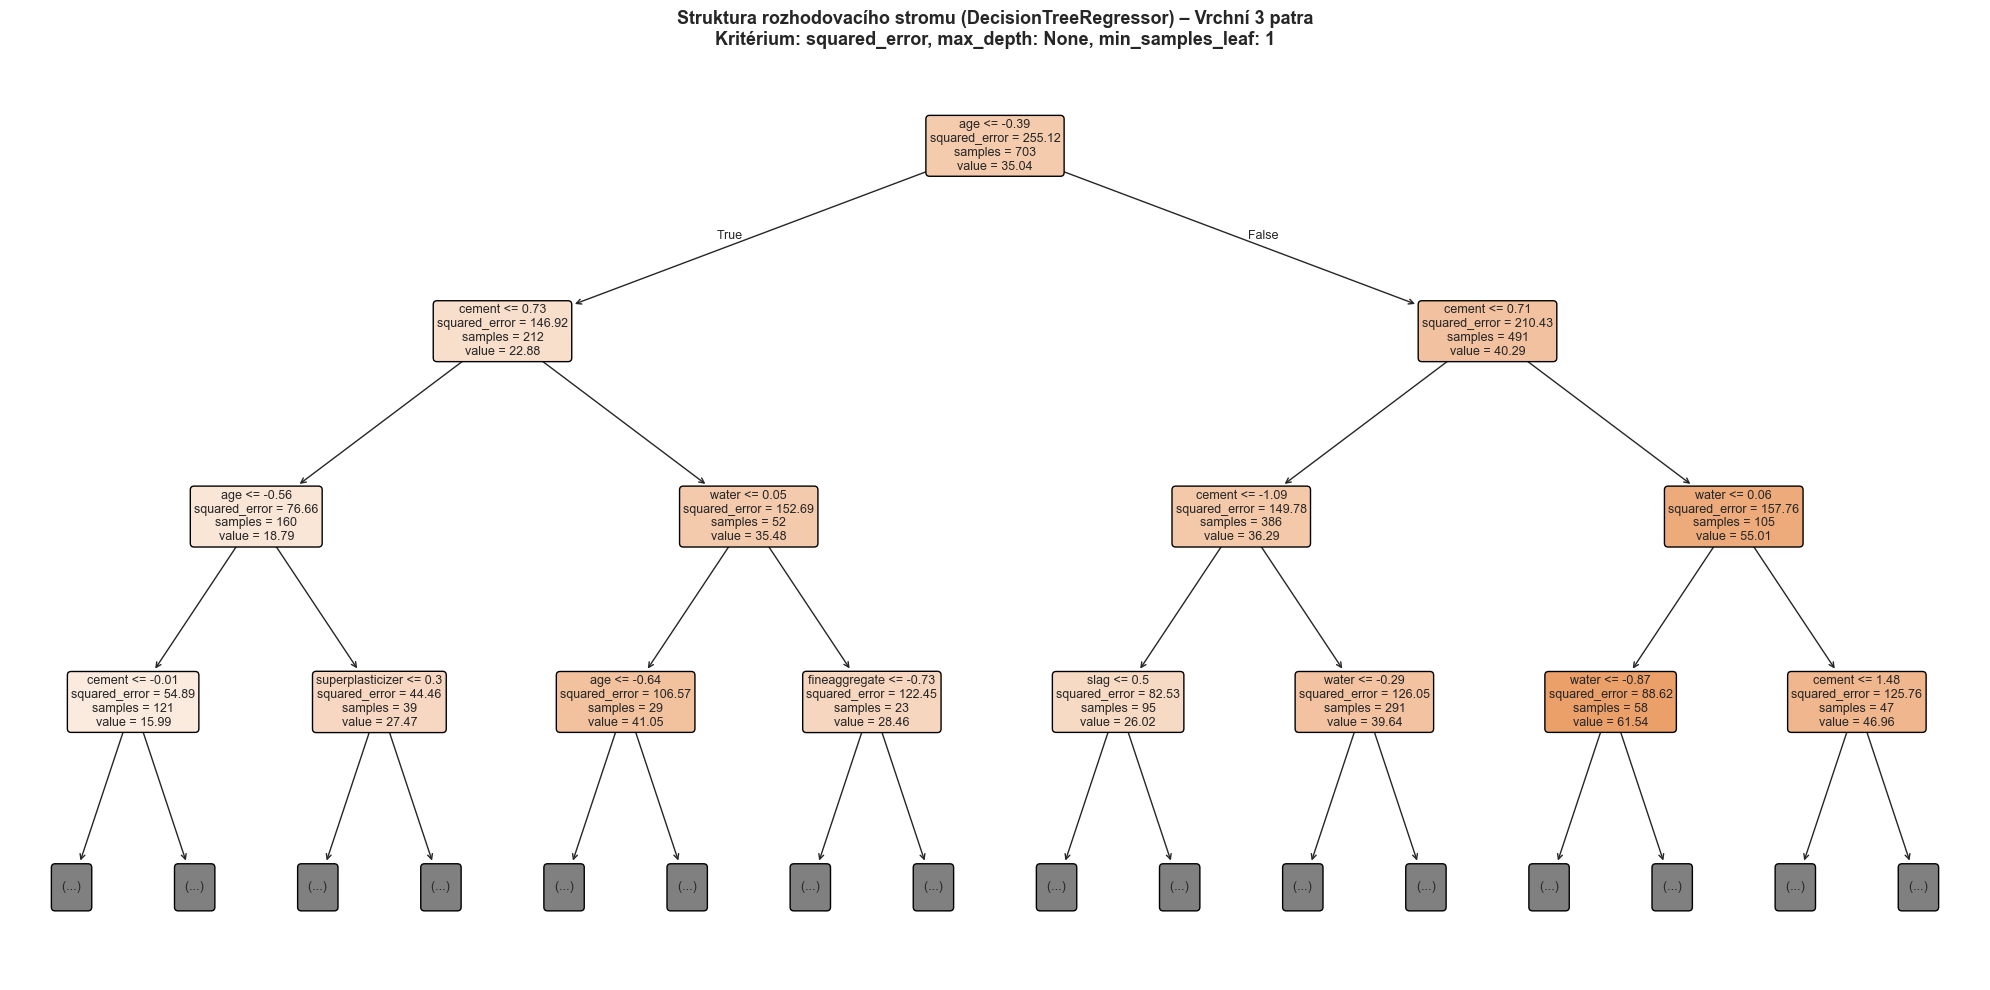

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg,
    max_depth=3,                          # Zobrazení vrchních 3 pater pro přehlednost
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    precision=2
)
plt.title(
    f"Struktura rozhodovacího stromu (DecisionTreeRegressor) – Vrchní 3 patra\n"
    f"Kritérium: {best_hyperparams['criterion']}, max_depth: {best_hyperparams['max_depth']}, min_samples_leaf: {best_hyperparams['min_samples_leaf']}",
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()


## 6. Otestování efektivity modelu
Dle zadání vypočteme:
1. **Koeficient determinace ($R^2$) na trénovací sadě.**
2. **Koeficient determinace ($R^2$) na testovací sadě.**
3. **Mean Squared Error (MSE) na testovací sadě.**
4. **Mean Absolute Error (MAE) na testovací sadě.**
5. Odmocninu MSE (RMSE) pro srovnání v jednotkách MPa.


In [7]:
# Predikce
y_pred_train = tree_reg.predict(X_train)
y_pred_test = tree_reg.predict(X_test)

# Výpočet požadovaných metrik
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

results_df = pd.DataFrame({
    'Metrika': [
        'Koeficient determinace (R²) – Train',
        'Koeficient determinace (R²) – Test',
        'Mean Squared Error (MSE) – Test',
        'Root Mean Squared Error (RMSE) – Test',
        'Mean Absolute Error (MAE) – Test',
        'Mean Absolute Percentage Error (MAPE) – Test'
    ],
    'Hodnota': [
        f"{train_r2:.4f} ({train_r2*100:.2f} %)",
        f"{test_r2:.4f} ({test_r2*100:.2f} %)",
        f"{test_mse:.4f}",
        f"{test_rmse:.4f} MPa",
        f"{test_mae:.4f} MPa",
        f"{test_mape:.2f} %"
    ]
})

display(results_df)


,Metrika,Hodnota
0,Koeficient determinace (R²) – Train,0.9968 (99.68 %)
1,Koeficient determinace (R²) – Test,0.8475 (84.75 %)
2,Mean Squared Error (MSE) – Test,43.8321
3,Root Mean Squared Error (RMSE) – Test,6.6206 MPa
4,Mean Absolute Error (MAE) – Test,4.4025 MPa
5,Mean Absolute Percentage Error (MAPE) – Test,15.30 %


## 7. Důležitost příznaků (Feature Importances) a srovnání s Lineární regresí

,Proměnná,Důležitost (%)
0,cement,36.0867
1,age,31.6913
2,water,12.0719
3,slag,10.6433
4,superplasticizer,3.3285
5,fineaggregate,2.6470
6,coarseaggregate,2.5466
7,flyash,0.9848


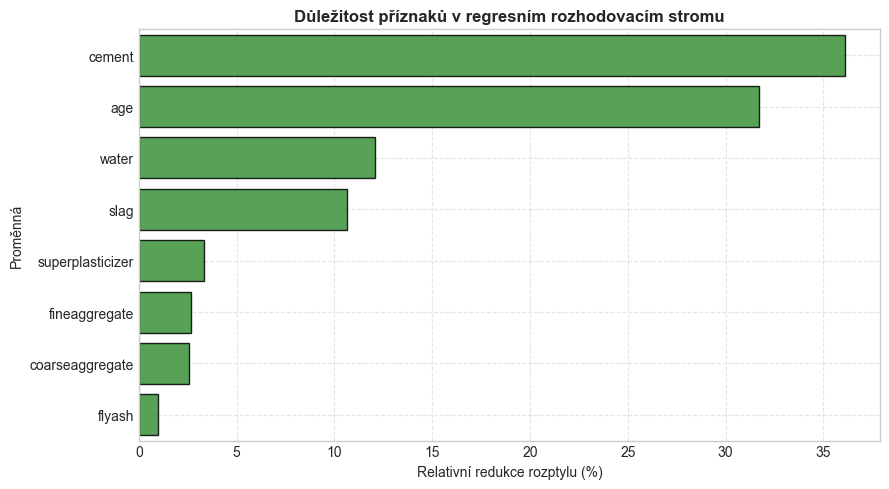

In [8]:
# Tabulka důležitosti příznaků
fi_df = pd.DataFrame({
    'Proměnná': X.columns,
    'Důležitost (%)': tree_reg.feature_importances_ * 100
}).sort_values(by='Důležitost (%)', ascending=False).reset_index(drop=True)

display(fi_df)

# Graf důležitosti
plt.figure(figsize=(9, 5))
sns.barplot(data=fi_df, x='Důležitost (%)', y='Proměnná', color='#2ca02c', edgecolor='black', alpha=0.85)
plt.title('Důležitost příznaků v regresním rozhodovacím stromu', fontsize=12, fontweight='bold')
plt.xlabel('Relativní redukce rozptylu (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Skutečnost vs. Predikce: Decision Tree vs. Lineární regrese

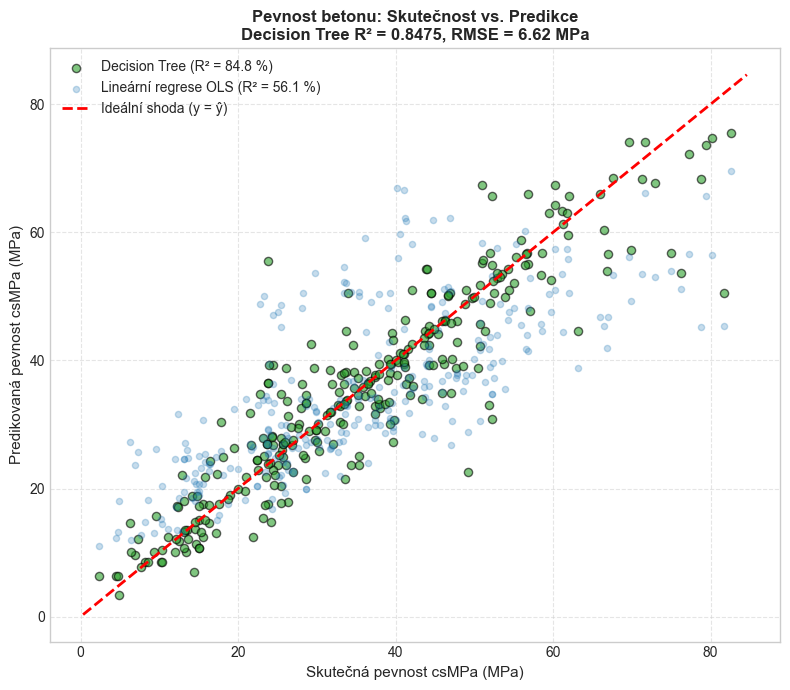

Zlepšení R² oproti lineární regresi: +28.67 %
Pokles chyby RMSE:                  -4.61 MPa (pokles o 41.1 %)


In [9]:
from sklearn.linear_model import LinearRegression

# OLS pro srovnání
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)
ols_r2 = r2_score(y_test, y_pred_ols)
ols_rmse = root_mean_squared_error(y_test, y_pred_ols)

plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_test, color='#2ca02c', alpha=0.6, edgecolors='k', s=35, label=f'Decision Tree (R² = {test_r2*100:.1f} %)')
plt.scatter(y_test, y_pred_ols, color='#1f77b4', alpha=0.25, s=20, label=f'Lineární regrese OLS (R² = {ols_r2*100:.1f} %)')

min_val = min(y_test.min(), y_pred_test.min()) - 2
max_val = max(y_test.max(), y_pred_test.max()) + 2
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideální shoda (y = ŷ)')

plt.title(f'Pevnost betonu: Skutečnost vs. Predikce\nDecision Tree R² = {test_r2:.4f}, RMSE = {test_rmse:.2f} MPa', fontsize=12, fontweight='bold')
plt.xlabel('Skutečná pevnost csMPa (MPa)', fontsize=11)
plt.ylabel('Predikovaná pevnost csMPa (MPa)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Zlepšení R² oproti lineární regresi: +{(test_r2 - ols_r2)*100:.2f} %")
print(f"Pokles chyby RMSE:                  -{(ols_rmse - test_rmse):.2f} MPa (pokles o {(1 - test_rmse/ols_rmse)*100:.1f} %)")


## 9. Závěrečné shrnutí a interpretace

1. **Dramatický nárůst přesnosti:**
   - Koeficient determinace na testovací sadě vzrostl z **56.08 % (Lineární regrese)** na **84.75 % (Rozhodovací strom)**.
   - Chyba **RMSE klesla z 11.24 MPa na 6.62 MPa** (pokles o 41.1 %).
   - Průměrná absolutní chyba **MAE klesla z 8.98 MPa na 4.40 MPa** (zlepšení o více než 50 %).

2. **Proč rozhodovací strom tak výrazně předčil lineární model?**
   - **Logaritmické stárnutí:** Stáří betonu (`age`) vysvětluje 31.69 % variance stromu. Strom dokáže vytvořit diskrétní prahy (např. $\text{age} \le 7$, $\text{age} \le 28$, $\text{age} \le 90$), což přirozeně kopíruje exponenciální hydrataci v prvních týdnech a následné nasycení pevnosti.
   - **Interakční členy:** Strom přirozeně zachycuje poměr vody a cementu ($w/c$). První větvení dělí data podle cementu a následně podle vody nebo stáří, čímž bez jakéhokoliv inženýrství příznaků modeluje nelineární chemické vazby.

3. **Nejdůležitější faktory pevnosti dle stromu:**
   1. **`cement` (36.09 %):** Hlavní nositel hydratačního tmelu.
   2. **`age` (31.69 %):** Doba zrání krystalické mřížky.
   3. **`water` (12.07 %):** Množství záměsové vody.
   4. **`slag` (10.64 %):** Vysokopecní struska jako sekundární pojivo.
